In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
23.1
---

In [ ]:
import folium
m =folium.Map(location=[10.761390474407522, 106.66828289315106], zoom_start=15)
folium.Marker(location=[10.761390474407522, 106.66828289315106],popup="Đại học Kinh tế TPHCM cơ sở B").add_to(m)
folium.Marker(location=[10.75934571460331, 106.67303149499647],popup="Bệnh Viện 30-4").add_to(m)
folium.Marker(location=[10.755128946542502, 106.67063102726281],popup="Bệnh Viện Nguyễn Tri Phương").add_to(m)
folium.Marker(location=[10.76100319448928, 106.66423739015127], popup="Sân Vận Động Thống Nhất").add_to(m)
folium.Marker(location=[10.758356993286686, 106.67292542509966],popup="Chợ An Đông").add_to(m)
m

---
23.2
---

In [ ]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="geoapi")
b=geolocator.geocode("Tu Du Hospital, Ho Chi Minh City")
d=(b.latitude,b.longitude)
m=folium.Map(location=[10.761390474407522, 106.66828289315106], zoom_start=15)
folium.Marker(location=[b.latitude,b.longitude],popup="Tu Du Hospital",color="red").add_to(m)
a={"Thong Nhat Stadium, Ho Chi Minh City",
   "Notre Dame Cathedral, Ho Chi Minh City",
   "University of Economics HCMC, Ho Chi Minh City",
   "Ben Thanh Market, Ho Chi Minh City",
   "An Dong Market, Ho Chi Minh City",
   "Đại học Kinh tế Thành phố Hồ Chí Minh - cơ sở B, Ho Chi Minh City",
   "Turtle Lake, Ho Chi Minh City",
   "Saigon Opera House, Ho Chi Minh City",
   "Le Quy Don High School, Ho Chi Minh City",
   "Independence Palace, Ho Chi Minh City"}
for i in a:
  loc = geolocator.geocode(i)
  #print(f'Tên: {loc.address}')
  c=(loc.latitude,loc.longitude)
  folium.Marker(location=[loc.latitude,loc.longitude],popup=i).add_to(m)
  dist=geodesic(c,d).km
  folium.PolyLine(locations=[[loc.latitude,loc.longitude],[b.latitude,b.longitude]],popup=dist).add_to(m)
m

---
23.3
---

In [40]:
from folium.plugins import HeatMap
import random

k = folium.Map(location=[10.8231, 106.6297], zoom_start=12)


data=[]

a=["Thong Nhat Stadium, Ho Chi Minh City",
   "Notre Dame Cathedral, Ho Chi Minh City",
   "University of Economics HCMC, Ho Chi Minh City",
   "Ben Thanh Market, Ho Chi Minh City",
   "An Dong Market, Ho Chi Minh City",
   "Đại học Kinh tế Thành phố Hồ Chí Minh - cơ sở B, Ho Chi Minh City",
   "Turtle Lake, Ho Chi Minh City",
   "Saigon Opera House, Ho Chi Minh City",
   "Le Quy Don High School, Ho Chi Minh City",
   "Independence Palace, Ho Chi Minh City"]

for i in a:
  loc = geolocator.geocode(i)
  if loc:
    data.append([loc.latitude,loc.longitude,random.randint(20,100)])


HeatMap(data).add_to(k)
k

---
23.4
---

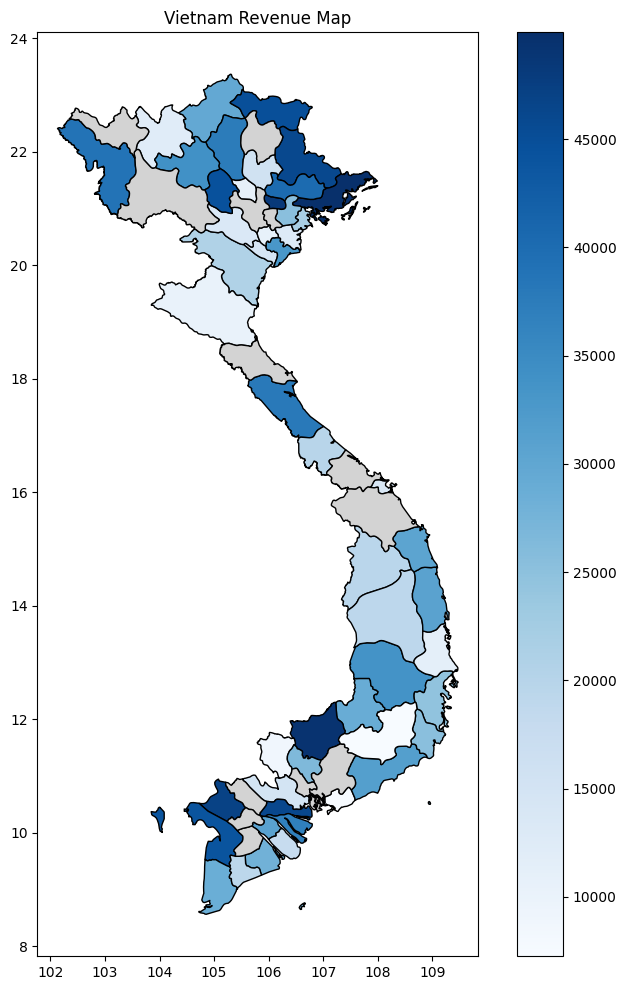

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import random


# đọc shapefile
gdf = gpd.read_file("/content/drive/MyDrive/AI/vn.shp", encoding="utf-8")

a = [
    'Hà Nội','Hồ Chí Minh','Đà Nẵng','Hải Phòng','Cần Thơ',
    'An Giang','Bà Rịa - Vũng Tàu','Bắc Giang','Bắc Kạn','Bạc Liêu',
    'Bắc Ninh','Bến Tre','Bình Định','Bình Dương','Bình Phước',
    'Bình Thuận','Cà Mau','Cao Bằng','Đắk Lắk','Đắk Nông',
    'Điện Biên','Đồng Nai','Đồng Tháp','Gia Lai','Hà Giang',
    'Hà Nam','Hà Tĩnh','Hải Dương','Hậu Giang','Hòa Bình',
    'Hưng Yên','Khánh Hòa','Kiên Giang','Kon Tum','Lai Châu',
    'Lâm Đồng','Lạng Sơn','Lào Cai','Long An','Nam Định',
    'Nghệ An','Ninh Bình','Ninh Thuận','Phú Thọ','Phú Yên',
    'Quảng Bình','Quảng Nam','Quảng Ngãi','Quảng Ninh','Quảng Trị',
    'Sóc Trăng','Sơn La','Tây Ninh','Thái Bình','Thái Nguyên',
    'Thanh Hóa','Thừa Thiên Huế','Tiền Giang','Trà Vinh',
    'Tuyên Quang','Vĩnh Long','Vĩnh Phúc','Yên Bái'
]

b = [random.randint(5000,50000) for _ in range(len(a))]

df = pd.DataFrame({
    "province": a,
    "revenue": b
})

gdf["key"] = gdf["name"]
df["key"] = df["province"]


merged = gdf.merge(df, on="key", how="left")

merged.plot(
    column="revenue",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    missing_kwds={"color": "lightgrey"},
    figsize=(10,12),
    aspect="auto"
)

plt.title("Vietnam Revenue Map")
plt.show()

---
23.5
---

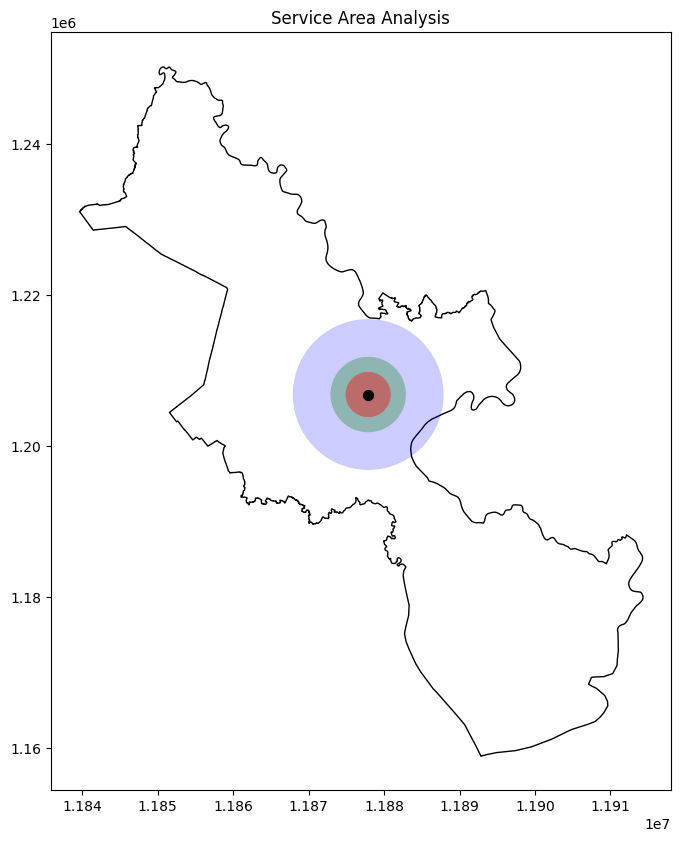

In [ ]:
from shapely.geometry import Point
import geopandas as gdp

center = gpd.GeoDataFrame(
    geometry=[Point(106.7009, 10.7769)],  # HCM
    crs="EPSG:4326"
)
gdf=gdp.read_file("/content/drive/MyDrive/AI/TP. Hồ Chí Minh - 63.shp")
center = center.to_crs(epsg=3857)
gdf = gdf.to_crs(epsg=3857)

buffer_3km = center.buffer(3000)
buffer_5km = center.buffer(5000)
buffer_10km = center.buffer(10000)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

gdf.plot(ax=ax, color="white", edgecolor="black")

gpd.GeoSeries(buffer_10km).plot(ax=ax, color="blue", alpha=0.2)
gpd.GeoSeries(buffer_5km).plot(ax=ax, color="green", alpha=0.3)
gpd.GeoSeries(buffer_3km).plot(ax=ax, color="red", alpha=0.4)

center.plot(ax=ax, color="black", markersize=50)

plt.title("Service Area Analysis")
plt.show()

In [ ]:
import folium

center_lat, center_lon = 10.7769, 106.7009

m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

folium.Circle(
    location=[center_lat, center_lon],
    radius=3000,
    color='red',
    fill=True,
    fill_opacity=0.3,
    popup='3 km'
).add_to(m)

folium.Circle(
    location=[center_lat, center_lon],
    radius=5000,
    color='green',
    fill=True,
    fill_opacity=0.2,
    popup='5 km'
).add_to(m)

folium.Circle(
    location=[center_lat, center_lon],
    radius=10000,
    color='blue',
    fill=True,
    fill_opacity=0.1,
    popup='10 km'
).add_to(m)

folium.Marker(
    [center_lat, center_lon],
    popup="Center",
    icon=folium.Icon(color="black")
).add_to(m)

m

---
23.6
---

In [ ]:
!pip install osmnx networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.1 MB/s eta 0:00:00


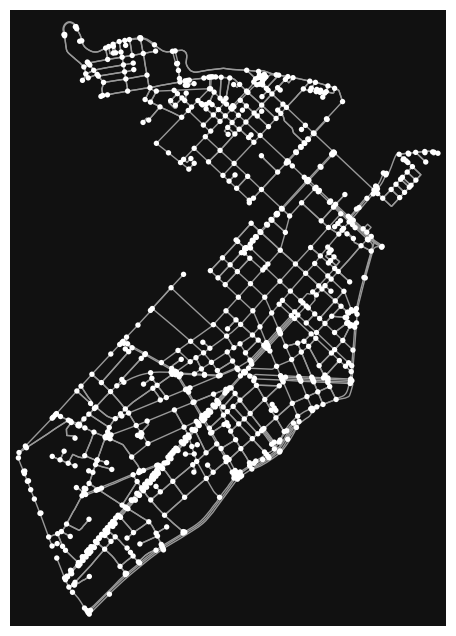

Nodes: 989
Edges: 2088
Avg road length: 79.0897525997606
Density: 260.0636034840244


In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

place = "District 1, Ho Chi Minh City, Vietnam"

G = ox.graph_from_place(place, network_type='drive')

ox.plot_graph(G)


num_nodes = len(G.nodes)
num_edges = len(G.edges)

print("Nodes:", num_nodes)
print("Edges:", num_edges)

lengths = [d['length'] for u, v, d in G.edges(data=True)]
avg_length = sum(lengths) / len(lengths)

print("Avg road length:", avg_length)

area = ox.geocode_to_gdf(place).to_crs(epsg=3857).area.values[0] / 1e6
density = num_edges / area

print("Density:", density)

---
23.7
---

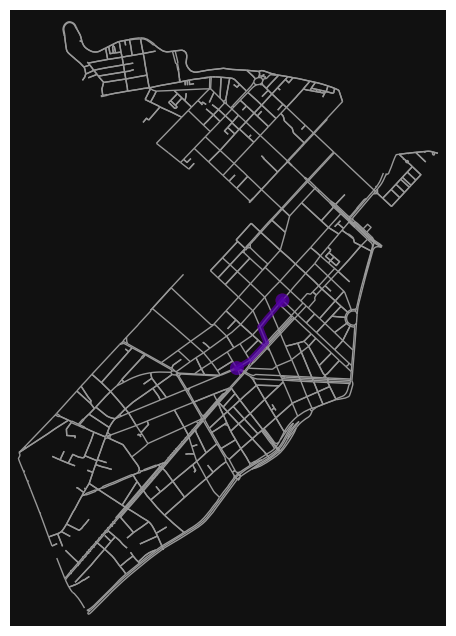

In [ ]:
import osmnx as ox
import networkx as nx

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive')

orig = (10.7769, 106.7009)  # UEH
dest = (10.7720, 106.6980)  # Bến Thành

orig_node = ox.distance.nearest_nodes(G, orig[1], orig[0])
dest_node = ox.distance.nearest_nodes(G, dest[1], dest[0])

route_dijkstra = nx.shortest_path(G, orig_node, dest_node, weight='length')

route_astar = nx.astar_path(G, orig_node, dest_node, weight='length')

fig, ax = ox.plot_graph_routes(
    G,
    [route_dijkstra, route_astar],
    route_colors=['red', 'blue'],
    route_linewidth=4,
    node_size=0
)

---
23.8
---

In [ ]:
import folium
import numpy as np
from scipy.spatial import distance_matrix

center = [10.7760, 106.7000]
np.random.seed(1)
customers = np.array([[center[0] + np.random.uniform(-0.01, 0.01),
                       center[1] + np.random.uniform(-0.01, 0.01)] for _ in range(10)])
drivers = np.array([[center[0] + np.random.uniform(-0.015, 0.015),
                     center[1] + np.random.uniform(-0.015, 0.015)] for _ in range(4)])

dist_min = distance_matrix(customers, drivers)
m = folium.Map(location=center, zoom_start=15, tiles='CartoDB positron')

for c_idx, dists in enumerate(dist_min):
    d_idx = np.argmin(dists)

    folium.CircleMarker(customers[c_idx], radius=5, color='blue', fill=True).add_to(m)

    folium.PolyLine([customers[c_idx], drivers[d_idx]], color='gray', weight=1, dash_array='5').add_to(m)

for d_loc in drivers:
    folium.Marker(d_loc, icon=folium.Icon(color='red', icon='car', prefix='fa')).add_to(m)

m

---
23.9
---

In [ ]:
import folium
from sklearn.cluster import KMeans
import numpy as np


center = [10.7760, 106.7000]
np.random.seed(42)
customers = np.array([[center[0] + np.random.uniform(-0.03, 0.03),
                       center[1] + np.random.uniform(-0.03, 0.03)] for _ in range(50)])

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, n_init=10).fit(customers)
centroids = kmeans.cluster_centers_

m = folium.Map(location=center, zoom_start=13, tiles='CartoDB positron')
colors = ['blue', 'green', 'purple']

for i, coord in enumerate(customers):
    cluster_id = kmeans.labels_[i]
    folium.CircleMarker(coord, radius=4, color=colors[cluster_id], fill=True).add_to(m)

for i, pos in enumerate(centroids):
    folium.Marker(pos, icon=folium.Icon(color='black', icon='warehouse', prefix='fa'),
                  popup=f"TRẠM TỐI ƯU {i+1}").add_to(m)

m


---
23.10
---

In [64]:
import osmnx as ox
import networkx as nx
import numpy as np
import folium

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive')

np.random.seed(0)

for u, v, k, data in G.edges(keys=True, data=True):
    risk = np.random.uniform(0, 1)  # giả lập tắc nghẽn
    data["risk"] = risk
    data["weight"] = data["length"] * (1 + risk)


orig = (10.7609631303892, 106.66796592383155)  # UEH
dest = (10.7720, 106.6980)  # Bến Thành

orig_node = ox.distance.nearest_nodes(G, orig[1], orig[0])
dest_node = ox.distance.nearest_nodes(G, dest[1], dest[0])

# ===== 4. ROUTING =====
# shortest path thường
route_short = nx.shortest_path(G, orig_node, dest_node, weight="length")

# path tránh tắc
route_safe = nx.astar_path(G, orig_node, dest_node, weight="weight")

# ===== 5. VẼ MAP (FOLIUM) =====
m = folium.Map(location=orig, zoom_start=14)

# convert graph → GeoDataFrame
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

# vẽ route thường (đỏ)
route1 = gdf_nodes.loc[route_short]
coords1 = [(y, x) for x, y in zip(route1.geometry.x, route1.geometry.y)]
folium.PolyLine(coords1, color="red", weight=5, popup="Shortest").add_to(m)

# vẽ route tránh tắc (xanh)
route2 = gdf_nodes.loc[route_safe]
coords2 = [(y, x) for x, y in zip(route2.geometry.x, route2.geometry.y)]
folium.PolyLine(coords2, color="blue", weight=5, popup="Avoid Traffic").add_to(m)

# marker
folium.Marker(orig, popup="Start").add_to(m)
folium.Marker(dest, popup="End").add_to(m)

m

---
23.11
---

In [ ]:
import folium
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


data = {
    'area': ['Quận 1', 'Quận 3', 'Quận 7', 'Quận Bình Thạnh', 'Quận Tân Bình'],
    'lat': [10.776, 10.781, 10.732, 10.810, 10.801],
    'lon': [106.701, 106.685, 106.715, 106.709, 106.651],
    'history_demand': [100, 80, 120, 90, 110] # Nhu cầu lịch sử
}
df = pd.DataFrame(data)

model = LinearRegression()
X = np.array(df['history_demand']).reshape(-1, 1)
y = df['history_demand'] * 1.2
model.fit(X, y)
df['predicted_demand'] = model.predict(X)

m = folium.Map(location=[10.776, 106.701], zoom_start=12)
for _, row in df.iterrows():
    folium.Circle(
        location=[row['lat'], row['lon']],
        radius=row['predicted_demand'] * 10,
        color='red', fill=True,
        popup=f"{row['area']}: Dự báo {int(row['predicted_demand'])} đơn"
    ).add_to(m)

m

---
23.12
---

In [42]:
import osmnx as ox
import networkx as nx
import folium
import numpy as np

place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')

kho_coords = (10.7760, 106.7000)
diem_giao_coords = [
    (10.782, 106.695),
    (10.770, 106.690),
    (10.785, 106.705)
]
all_points = [kho_coords] + diem_giao_coords

nodes = [ox.nearest_nodes(G, p[1], p[0]) for p in all_points]


route_nodes = []
for i in range(len(nodes)-1):
    path = nx.shortest_path(G, nodes[i], nodes[i+1], weight='length')
    route_nodes.extend(path[:-1])
return_path = nx.shortest_path(G, nodes[-1], nodes[0], weight='length')
route_nodes.extend(return_path)

route_coords = [[G.nodes[node]['y'], G.nodes[node]['x']] for node in route_nodes]

m = folium.Map(location=kho_coords, zoom_start=15)

folium.Marker(kho_coords, popup="KHO TỔNG", icon=folium.Icon(color='red', icon='home')).add_to(m)
for i, p in enumerate(diem_giao_coords):
    folium.Marker(p, popup=f"Điểm giao {i+1}", icon=folium.Icon(color='blue')).add_to(m)

folium.PolyLine(route_coords, color="green", weight=5, opacity=0.7).add_to(m)

m

---
23.13
---

In [65]:
import folium

m = folium.Map(location=[10.776, 106.701], zoom_start=13)

folium.FeatureGroup(name='Vùng phục vụ').add_child(
    folium.Circle([10.776, 106.701], radius=3000, fill=True, color='orange', opacity=0.2)
).add_to(m)


fg_shops = folium.FeatureGroup(name='Cửa hàng')
for i in range(3):
    folium.Marker([10.78 + i*0.01, 106.70], popup=f"Shop {i+1}").add_to(fg_shops)
fg_shops.add_to(m)


folium.PolyLine([[10.776, 106.701], [10.81, 106.75]], color="blue", weight=5, name="Tuyến chính").add_to(m)

folium.LayerControl().add_to(m)
m

---
23.14
---

In [51]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')

start_node = ox.nearest_nodes(G, 106.6948, 10.7712) # Chợ Bến Thành
end_node = ox.nearest_nodes(G, 106.7031, 10.7825)   # Nhà thờ Đức Bà

route = nx.shortest_path(G, start_node, end_node, weight='length')
route_coords = [(G.nodes[node]['x'], G.nodes[node]['y']) for node in route]

fig, ax = ox.plot_graph(G, show=False, close=False, edge_color='#999999', node_size=0)
line, = ax.plot([], [], 'ro', markersize=10, label='Xe đang di chuyển')

def update(frame):
    x, y = route_coords[frame]
    line.set_data([x], [y])
    return line,

ani = FuncAnimation(fig, update, frames=len(route_coords), interval=200, blit=True)

plt.title("23.14: Mô phỏng xe di chuyển Real-time")
plt.legend()

plt.close()
HTML(ani.to_html5_video())


---
23.15 Sử dụng DBSCAN phát hiện mật độ
---

In [78]:
import numpy as np
import pandas as pd
import folium
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import numpy as np


np.random.seed(0)
center_lat, center_lon = 10.7769, 106.7009

lats = center_lat + np.random.normal(0, 0.02, 200)
lons = center_lon + np.random.normal(0, 0.02, 200)

df = pd.DataFrame({"lat": lats, "lon": lons})
coords = df[["lat","lon"]].values

db = DBSCAN(eps=0.01, min_samples=3).fit(coords)
df["cluster"] = db.labels_

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

for _, row in df.iterrows():
    folium.CircleMarker(
        [row["lat"], row["lon"]],
        radius=3,
        color=["red","blue","green","grey"][int(row["cluster"])],
        fill=True
    ).add_to(m)

m
